# **Applications of Principal Component Analysis (PCA)**

### Objectives
* Use Principal Component Analysis (PCA) to project 2-D data onto its principal axes
* Use PCA for feature space dimensionality reduction
* Relate explained variance to feature importance and noise reduction

### Introduction
1. The first application illustrates how you can use PCA to project 2-D data onto its principal axes, meaning the two orthogonal directions that explain most of the variance in the data.

2. For the second application, you will use PCA to project higher dimensional data down to a lower dimensional feature space. This is an example of dimensional reduction, a powerful technique that has multiple benefits, including reducing your model-building computational load and, in many cases, the accuracy of your model. PCA can help you filter out redundant, linearly correlated variables and reduce the amount of noise in the data.

---

### Part I: Using PCA to project 2-D data onto its principal axes

Here, we will illustrate how you can use PCA to transform our 2-D data to represent it in terms of its principal axes - the projection of our data onto the two orthogonal directions that explain most of the variance in our data.

In [1]:
# Load Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

#### Create dataset

Let's create a 2-dimensional dataset containing two linearly correlated features. We'll use a bivariate normal distribution. Both features, X1 and X2, will have zero mean and a covariance given by the (symmetric) convariance matrix:

\begin{equation}
\begin{pmatrix}
  3  & 2     \\\\\\\\
  2  & 2     \\
\end{pmatrix}
\end{equation}

Here, the diagonal elements define the variances of X1 and X2 (3 and 2, respectively), while the off-diagonal element is the covariance (2) between X1 and X2, which expresses how similarly these features vary.

In [2]:
np.random.seed(42)
mean = [0,0]
cov = [[3,2], [2,2]]
X = np.random.multivariate_normal(mean=mean, cov=cov, size=200)

In [4]:
X.shape

(200, 2)

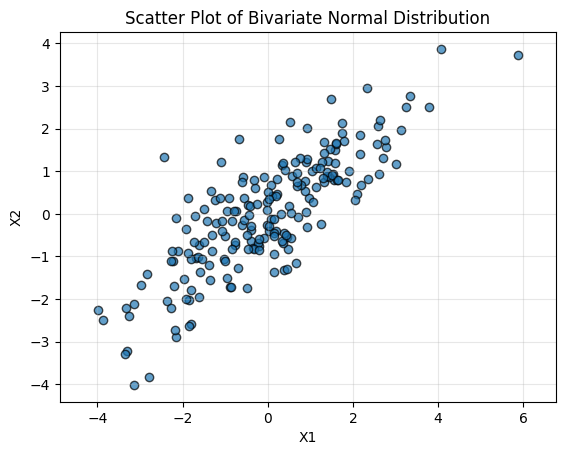

In [12]:
# Visualize
plt.figure()
plt.scatter(X[:, 0],X[:,1], ec='k', alpha=0.7)
plt.title("Scatter Plot of Bivariate Normal Distribution")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

Consider the main direction the data follows in the scatterplot. It's actually the direction of the first principal component. We can use PCA to determine this direction.

#### Perform PCA on the dataset
Next, we'll initialize a 2-component PCA model with default paremeters and then fit and transform the feature space in one step.

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#### Get the principal components from the model
The principal components are the principal axes, represented in feature space coordinates, which align with the directions of maximum variance in our data.

In [14]:
components = pca.components_
components

array([[ 0.78215821,  0.62307987],
       [-0.62307987,  0.78215821]])

This principal components are sorted in decreasing order by their explained variance, which can be expressed as a ratio:

In [26]:
var_ratio = pca.explained_variance_ratio_

print(f"First Component: {var_ratio[0]:.2%}")
print(f"Second Component: {var_ratio[1]:.2%}")

First Component: 91.12%
Second Component: 8.88%


#### Display the results
Here, we'll use a scatterplot to display the data points in their original feature space, X1, X2. We'll also plot the projections of the data points onto their principal component directions. It's a bit technical, requiring some understanding of linear algebra, but the outcome will be instructive.

#### Project the data onto its principal component axes
The projection of the data onto a given principal component yields the coordinates of each of the data points along that component's direction.

The new coordinates are given by the dot products of each point's coordinates with the given PCA component.

Specifically, the projections are given by:

In [27]:
projection_pc1 = np.dot(X, components[0])
projection_pc2 = np.dot(X, components[1])

Now that you have these coordinates, we can use them to represent the projections of each data point along the principal directions in the original feature space.

In [29]:
x_pc1 = projection_pc1 * components[0][0]
y_pc1 = projection_pc1 * components[0][1]
x_pc2 = projection_pc2 * components[1][0]
y_pc2 = projection_pc2 * components[1][1]

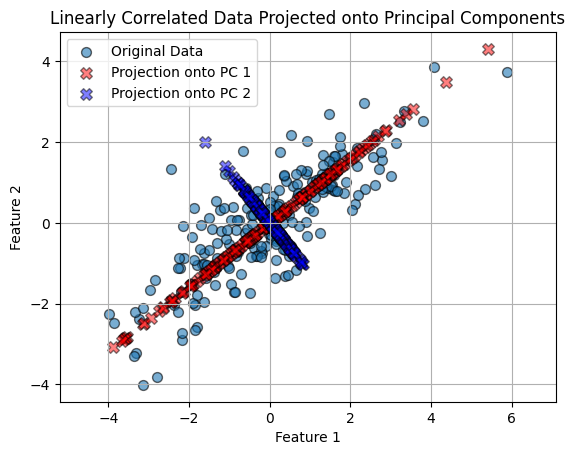

In [30]:
# Plot the results

# Plot original data
plt.figure()
plt.scatter(X[:, 0], X[:, 1], label='Original Data', ec='k', s=50, alpha=0.6)

# Plot the projections along PC1 and PC2
plt.scatter(x_pc1, y_pc1, c='r', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 1')
plt.scatter(x_pc2, y_pc2, c='b', ec='k', marker='X', s=70, alpha=0.5, label='Projection onto PC 2')
plt.title('Linearly Correlated Data Projected onto Principal Components', )
plt.xlabel('Feature 1',)
plt.ylabel('Feature 2',)
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

The data varies in two main directions. 

* The first directions, in red, is aligned in the direction having the widest variation.
* The second directions, in blue, is perpendicular to first and has a lower variance.

---

## Part II: PCA for feature space dimensionality reduction

For this second application, we'll use PCA to project the four-dimensional iris feature data set down onto a two-dimensional feature space.

This will have the added benefit of enabling us to visualize some of the most important structures in the dataset.

#### Load and preprocess Iris data

In [31]:
# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
X_scaled.shape

(150, 4)

In [34]:
target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [35]:
# Initialize a PCA model
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [38]:
X_pca.shape

(150, 2)

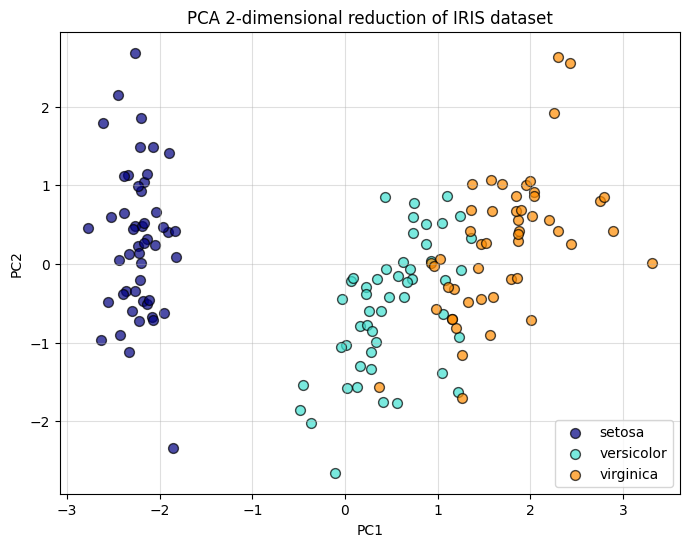

In [37]:
# Plot the PCA-transformed data in 2D
plt.figure(figsize=(8,6))

colors = ['navy', 'turquoise', 'darkorange']
lw = 1

for color, i, target_name in zip(colors, [0,1,2], target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], color=color, s=50, ec='k', alpha=0.7, lw=lw,
                label=target_name)
    
plt.title("PCA 2-dimensional reduction of IRIS dataset")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(loc='best', shadow=False, scatterpoints=1)
plt.grid(True, alpha=0.4)
plt.show()

#### Reflection
Examine the plot and consider how well the Iris classes have been separated simply by projecting the feature space down to two principal components.

In [44]:
100*pca.explained_variance_ratio_.sum()

95.81320720000164